[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/session1_weavers_three_cases.ipynb)


# Weaver's Three Kinds of Problems — A Hands-On Tour

Weaver (1948) argued that science had only really mastered two kinds of problems, leaving a huge
middle ground — **organized complexity** — mostly untouched. This notebook builds all three, one
at a time, and instead of just eyeballing a plot and saying "that looks more/less predictable," we
actually **measure** how predictable each one is, using the same simple test throughout:

> Change one small thing (repeat the run exactly, use a different random seed, or nudge the setup
> slightly) — how much does the result move?

Two properties will do the real explanatory work across all three cases, matching the course's
mind map for this session:

- **Organic interrelation** — Weaver's own term. Are the variables tangled together as a whole,
  or not?
- **Reflexivity** — do the parts *observe* the aggregate (or each other) and change their own
  behavior because of what they see?

**How each case is presented:** every function gets a short **pseudocode** cell right before its
**code** cell. The code's comments are numbered to match the pseudocode steps exactly — read the
pseudocode first, then find each numbered step inside the code below it.


In [23]:
# Core libraries used throughout this notebook
import numpy as np              # numerical arrays, random number generation, math
import matplotlib.pyplot as plt # plotting
import pandas as pd             # tables for comparing results across cases/seeds

# Make every plot in this notebook a consistent size and easier to read
plt.rcParams["figure.figsize"] = (7, 4.5)  # width, height in inches
plt.rcParams["axes.grid"] = True           # light grid lines on by default

print("Ready.")  # simple check that this cell ran without errors


Ready.


---
## Case 1 — Simplicity

**Everyday example:** you throw a ball. Two numbers — launch angle and speed — determine the
entire flight path. No individuals, no randomness, nothing hidden. This is the kind of problem
classical physics mastered first.

**On interrelation and reflexivity:** with only 2 variables, there's nothing to be interrelated
*or* reflexive about — the concepts don't even apply yet. That's part of what makes this case
simple.


### Pseudocode — `ball_path`

1. Convert the launch angle from degrees to radians (Python's trig functions expect radians)
2. Split the launch speed into a horizontal part (`vx`) and a vertical part (`vy`), using the angle
3. Compute the total flight time — how long until the ball falls back to height 0
4. Build a list of 200 evenly-spaced time points from launch to landing
5. At every one of those time points, compute the ball's `x` position (steady horizontal motion)
6. At every one of those time points, compute the ball's `y` position (horizontal motion pulled down by gravity)
7. Return the full `x` and `y` arrays — the entire flight path


In [24]:
GRAVITY = 9.81       # a constant, doesn't change
LAUNCH_SPEED = 20.0  # also fixed for this whole notebook

def ball_path(angle_degrees):
    """Compute the (x, y) flight path of a ball thrown at `angle_degrees`."""
    angle = np.radians(angle_degrees)              # (1) degrees -> radians

    vx = LAUNCH_SPEED * np.cos(angle)               # (2) horizontal speed component
    vy = LAUNCH_SPEED * np.sin(angle)               # (2) vertical speed component

    flight_time = 2 * vy / GRAVITY                  # (3) total time in the air

    t = np.linspace(0, flight_time, 200)            # (4) 200 time points, launch to landing

    x = vx * t                                      # (5) horizontal position at each time point
    y = vy * t - 0.5 * GRAVITY * t**2                # (6) vertical position at each time point
    return x, y                                     # (7) the full path


### Pseudocode — `landing_distance`

1. Get the full flight path from `ball_path`
2. The landing distance is just the very last `x` value in that path


In [25]:
def landing_distance(angle_degrees):
    """How far the ball travels before it lands."""
    x, y = ball_path(angle_degrees)   # (1) get the full path
    return x[-1]                      # (2) last x-value = where it landed


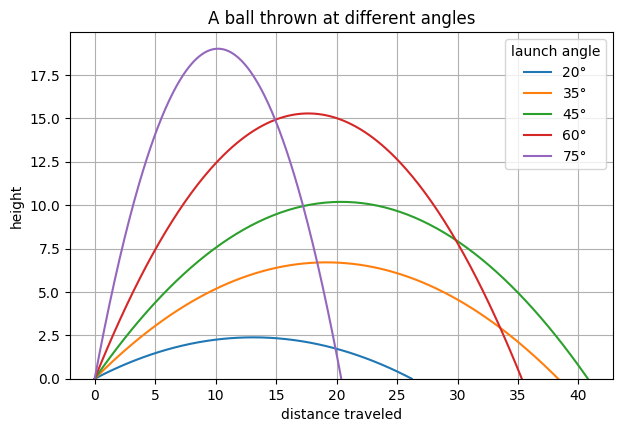

In [4]:
plt.figure()
for angle in [20, 35, 45, 60, 75]:
    x, y = ball_path(angle)
    plt.plot(x, y, label=f"{angle}°")
plt.title("A ball thrown at different angles")
plt.xlabel("distance traveled")
plt.ylabel("height")
plt.legend(title="launch angle")
plt.ylim(bottom=0)
plt.show()


### Reproducibility test: run the exact same throw twice

This is the baseline every other case in this notebook gets compared against.


In [26]:
run_1 = landing_distance(45)
run_2 = landing_distance(45)

case1_stats = pd.DataFrame([{
    "case": "1. Simplicity",
    "what we changed": "nothing -- exact repeat",
    "what we measured": "landing distance",
    "run 1": round(run_1, 6),
    "run 2": round(run_2, 6),
    "difference": round(abs(run_1 - run_2), 6),
}]).set_index("case")

case1_stats


,what we changed,what we measured,run 1,run 2,difference
case,,,,,
1. Simplicity,nothing -- exact repeat,landing distance,40.77472,40.77472,0.0


**Takeaway:** the difference is exactly 0. Not "very small" — exactly zero. Same input, same
output, always. That's the signature of simplicity.


---
## Case 2 — Disorganized complexity

**Everyday example:** gas molecules bouncing around a box, or hundreds of people wandering a plaza
with no destination, bumping and changing direction at random. No individual path is predictable.
Let's check whether the **group** is.

**On interrelation and reflexivity:** millions of variables here, but *not* interrelated — each
particle bounces off walls independently of what any other particle is doing. And no reflexivity
either: a particle doesn't observe the average speed of the population and adjust its own velocity
because of it. That combination — many variables, no interrelation, no reflexivity — is exactly
why the statistical method works.


### Pseudocode — `create_particles`

1. Give every particle a random starting position, somewhere inside the box
2. Give every particle a random starting velocity (direction and speed)
3. Return the full set of positions and velocities


In [27]:
def create_particles(n_particles, box_size, rng):
    """Give each particle a random starting position and a random velocity."""
    positions = rng.uniform(0, box_size, size=(n_particles, 2))   # (1) random (x, y) per particle
    velocities = rng.normal(0, 1.0, size=(n_particles, 2))        # (2) random (vx, vy) per particle
    return positions, velocities                                  # (3) both arrays


### Pseudocode — `move_particles` and `bounce_off_walls`

Moving the particles is really two separate ideas, so we'll write two small functions:

**`move_particles`**
1. Slide every particle forward by `velocity * dt` (a small time step)

**`bounce_off_walls`**
1. For the x-axis, then again for the y-axis:
   1. Find every particle that went past the box's edge on that axis
   2. Flip that particle's velocity on that axis (bounce)
   3. Push the particle's position back to just inside the box


In [28]:
def move_particles(positions, velocities, dt):
    """Slide every particle forward by one small time step."""
    return positions + velocities * dt   # (1) position += velocity * time


def bounce_off_walls(positions, velocities, box_size):
    """If a particle crossed a wall, push it back inside and flip its velocity
    on that axis -- like a ball bouncing off a real wall."""
    for dim in range(2):   # (1) dim 0 = x-axis, dim 1 = y-axis -- run the same steps for both
        went_out_of_bounds = (positions[:, dim] < 0) | (positions[:, dim] > box_size)  # (1.1)
        velocities[went_out_of_bounds, dim] *= -1                                       # (1.2)
        positions[:, dim] = np.clip(positions[:, dim], 0, box_size)                     # (1.3)
    return positions, velocities


### Pseudocode — `step_particles`

1. Move every particle forward one time step
2. Bounce anyone who crossed a wall back inside
3. Return the updated positions and velocities


In [29]:
def step_particles(positions, velocities, box_size, dt):
    """Advance every particle by one time step: move, then bounce off walls."""
    positions = move_particles(positions, velocities, dt)                    # (1)
    positions, velocities = bounce_off_walls(positions, velocities, box_size) # (2)
    return positions, velocities                                             # (3)


### Pseudocode — `run_particle_simulation`

1. Create the starting positions and velocities for all particles
2. Repeat, once per time step, for the whole simulation:
   1. Advance every particle by one step (move + bounce)
3. Once all steps are done, compute everyone's final speed
4. Return the final positions and speeds


In [30]:
def run_particle_simulation(seed, n_particles=300, box_size=10.0, n_steps=200, dt=0.05):
    """Run the whole simulation for one random seed and return where everyone
    ended up, plus everyone's final speed."""
    rng = np.random.default_rng(seed)
    positions, velocities = create_particles(n_particles, box_size, rng)   # (1)

    for _ in range(n_steps):                                              # (2)
        positions, velocities = step_particles(positions, velocities, box_size, dt)  # (2.1)

    speeds = np.linalg.norm(velocities, axis=1)   # (3) speed = length of the velocity vector
    return positions, speeds                       # (4)


To actually *see* the randomness Case 2 is about, a single final position isn't enough --
we need each particle's full path. This reuses the exact same `step_particles` function
from before; it just remembers every position along the way instead of only the last one.


### Pseudocode — `run_particle_simulation_with_trajectories`

Same shape as `run_particle_simulation`, with one addition:

1. Create the starting positions and velocities (for a small sample -- 20 particles, not 300)
2. Save the starting positions as step 0 of the trajectory record
3. Repeat, once per time step:
   1. Advance every particle by one step
   2. Save this step's positions onto the trajectory record
4. Return the full trajectory record (every particle's position, at every step)


In [10]:
def run_particle_simulation_with_trajectories(seed, n_particles=20, box_size=10.0, n_steps=200, dt=0.05):
    """Same idea as run_particle_simulation, but keeps every intermediate position too,
    so we can draw each particle's full path, not just where it ended up.
    Uses far fewer particles than the full run (20 instead of 300) -- storing a full
    trajectory for 300 particles would be a lot of data for very little extra insight."""
    rng = np.random.default_rng(seed)
    positions, velocities = create_particles(n_particles, box_size, rng)   # (1)

    trajectory = [positions.copy()]                # (2) step 0: everyone's starting position
    for _ in range(n_steps):                        # (3)
        positions, velocities = step_particles(positions, velocities, box_size, dt)  # (3.1)
        trajectory.append(positions.copy())         # (3.2)

    # shape: (n_steps + 1, n_particles, 2) -- one (x, y) pair per particle per step
    return np.array(trajectory)                     # (4)


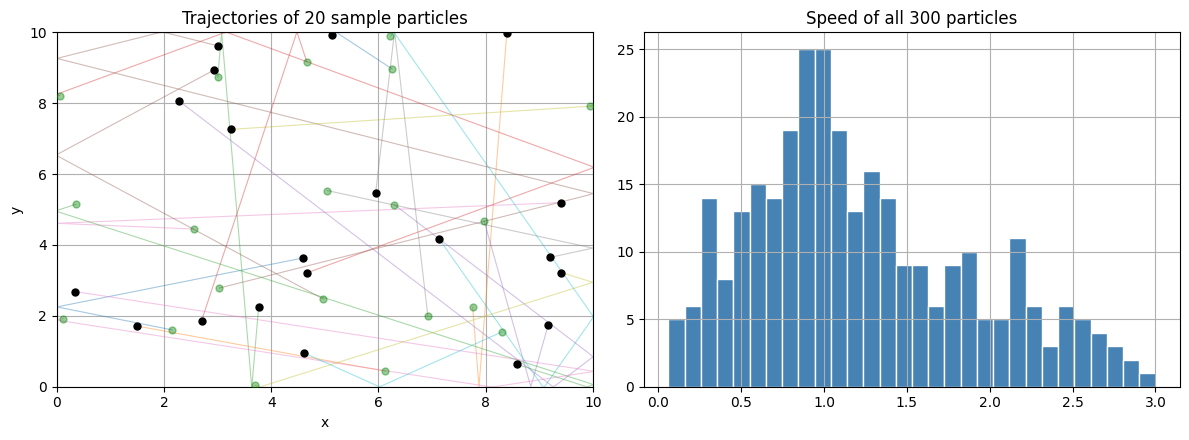

In [11]:
trajectory = run_particle_simulation_with_trajectories(seed=7)   # 20 particles, full path
positions, speeds = run_particle_simulation(seed=7)               # 300 particles, final speeds only

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

n_particles_shown = trajectory.shape[1]
for i in range(n_particles_shown):
    x_path = trajectory[:, i, 0]
    y_path = trajectory[:, i, 1]
    axes[0].plot(x_path, y_path, alpha=0.4, linewidth=0.8)                            # the path taken
    axes[0].scatter(x_path[0], y_path[0], color="green", s=25, alpha=0.4, zorder=3)   # start -- faded
    axes[0].scatter(x_path[-1], y_path[-1], color="black", s=25, alpha=1.0, zorder=4) # end -- solid
axes[0].set_title(f"Trajectories of {n_particles_shown} sample particles")
axes[0].set_xlim(0, 10); axes[0].set_ylim(0, 10)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

axes[1].hist(speeds, bins=30, color="steelblue", edgecolor="white")
axes[1].set_title(f"Speed of all {len(speeds)} particles")
plt.tight_layout()
plt.show()


### Reproducibility test: one individual vs. the group, across 5 different random seeds

We'll track two things for each seed: where one specific particle (#0) ends up, and what the
**average** speed of the whole population is.


In [12]:
records = []
for seed in [1, 2, 3, 4, 5]:
    positions, speeds = run_particle_simulation(seed=seed)
    records.append({
        "seed": seed,
        "particle #0's final x-position": round(positions[0, 0], 3),
        "average speed, all particles": round(speeds.mean(), 4),
    })

case2_runs = pd.DataFrame(records)
case2_runs


,seed,particle #0's final x-position,"average speed, all particles"
0,1,5.544,1.3214
1,2,8.230,1.2765
2,3,6.463,1.2657
3,4,1.986,1.3053
4,5,1.945,1.2225


In [13]:
box_width = 10.0

one_particle_spread_pct = 100 * (
    case2_runs["particle #0's final x-position"].max()
    - case2_runs["particle #0's final x-position"].min()
) / box_width

group_average_spread_pct = 100 * (
    case2_runs["average speed, all particles"].std()
    / case2_runs["average speed, all particles"].mean()
)

print(f"One particle's position swings across {one_particle_spread_pct:.0f}% of the box, run to run.")
print(f"The population's average speed varies by only {group_average_spread_pct:.1f}%, run to run.")


One particle's position swings across 63% of the box, run to run.
The population's average speed varies by only 3.0%, run to run.


**Takeaway:** you cannot predict where particle #0 will be — it's all over the box depending on
the random seed. But the **average speed of the whole population** barely moves at all between
runs. Individually unpredictable, collectively stable — exactly Weaver's disorganized-complexity
claim, now with a number attached to each half of it. Note this holds up *without* interrelation
or reflexivity being present anywhere in the system.


---
## On to Case 3 — but first, a gap in Weaver's own paper

Weaver named a third category — **organized complexity** — where variables are genuinely
**interrelated into an organic whole**, not scattered at random (his own criterion). But he wrote
in 1948, and he never specified a mechanism for it: no equations, no algorithm, nothing you could
actually build and run.

What follows borrows a mechanism from later complexity science to make that interrelation
concrete: **memory and feedback**. This is *not* Weaver's own vocabulary, and it's also a
different, narrower notion of "memory" than the one this course's mind map uses for Simon
(1991)'s *organizational* memory — here it's just a running tally of where walkers have stepped
before, not accumulated expertise distributed across role-holders. We'll flag it explicitly
wherever it does real work, so it stays clear what's Weaver's argument and what's borrowed
machinery.


---
## Case 3 — Organized complexity

**Setup:** walkers moving across a grid between three fixed "buildings." Like the NetLogo model
this is based on, walkers **always know exactly where their destination is** — an omniscient
"compass." We're not modeling search-and-discovery here.

**What we're actually testing is much narrower:** when a walker has several equally-good steps
available, does it choose based on the past, or not? That single difference is the entire
experiment. Everything else — the world, the walkers, the destinations, which steps are even
allowed — is identical in both models we'll compare.

**On interrelation and reflexivity:** in Model A, walkers are goal-directed but still *not*
interrelated with each other — one walker's path has no bearing on another's. Model B changes
that: walkers observe the *aggregate* of everyone's past footsteps (popularity) and adjust their
own choice because of it — and their own choice then feeds back into that same aggregate. That's
both organic interrelation and reflexivity, together, for the first time in this notebook.


In [14]:
WIDTH, HEIGHT = 41, 31
BUILDINGS = [(3, 5), (3, 25), (37, 15)]

print(f"A {WIDTH} x {HEIGHT} grid with {len(BUILDINGS)} buildings: {BUILDINGS}")


A 41 x 31 grid with 3 buildings: [(3, 5), (3, 25), (37, 15)]


### Pseudocode — `squared_distance` and `closer_neighbors`

A walker only ever considers the up-to-8 neighboring cells that would take it **strictly closer**
to its destination.

**`squared_distance`**
1. Return the squared straight-line distance between two points (no square root needed -- we only
   ever *compare* distances, never need their actual size)

**`closer_neighbors`**
1. Measure the walker's current distance to its goal
2. For each of the 8 surrounding directions:
   1. Skip it if it falls outside the grid
   2. Otherwise, measure the distance to the goal *from that neighboring cell*
   3. If that distance is smaller than the current distance, this cell qualifies -- keep it
3. Return the list of all qualifying ("closer") cells


In [15]:
def squared_distance(x1, y1, x2, y2):
    """Squared straight-line distance between two points."""
    return (x1 - x2) ** 2 + (y1 - y2) ** 2   # (1)


def closer_neighbors(x, y, goal_x, goal_y):
    """Return every neighboring cell that is strictly closer to (goal_x, goal_y)
    than (x, y) currently is."""
    current_distance = squared_distance(x, y, goal_x, goal_y)   # (1)

    eight_directions = [
        (1, 0), (-1, 0), (0, 1), (0, -1),
        (1, 1), (1, -1), (-1, 1), (-1, -1),
    ]

    closer_cells = []
    for dx, dy in eight_directions:                             # (2)
        nx, ny = x + dx, y + dy
        if 0 <= nx < WIDTH and 0 <= ny < HEIGHT:                # (2.1) skip if off-grid
            if squared_distance(nx, ny, goal_x, goal_y) < current_distance:  # (2.2)
                closer_cells.append((nx, ny))                   # (2.3) qualifies -- keep it

    return closer_cells                                         # (3)


# quick sanity check: standing at (10, 10), heading to building (37, 15)
print("Example -- cells that get you closer:", closer_neighbors(10, 10, 37, 15))


Example -- cells that get you closer: [(11, 10), (10, 11), (11, 11), (11, 9)]


### Pseudocode — `choose_randomly`, `choose_most_popular`, `choose_next_cell`

Usually a walker has 2 or 3 equally "closer" cells to choose from. **How it breaks that tie is
the entire experiment.**

**`choose_randomly`**
1. Pick one of the candidate cells uniformly at random

**`choose_most_popular`**
1. Look up how many times each candidate cell has already been stepped on
2. Find the highest of those popularity values
3. Keep only the candidates that share that highest value (there may be a tie)
4. Pick randomly among those tied, most-popular candidates

**`choose_next_cell`** (the actual Model A / Model B switch)
1. If this is Model A (`use_memory=False`), OR if this is Model B but we landed on the
   "still exploring" roll of the dice (probability `1 - follow_probability`) -- choose randomly
2. Otherwise (Model B, and we didn't roll "explore") -- choose the most popular candidate


In [16]:
def choose_randomly(candidates, rng):
    """Pick uniformly at random among the candidate cells."""
    idx = rng.integers(len(candidates))   # (1)
    return candidates[idx]                # (1)


def choose_most_popular(candidates, popularity, rng):
    """Pick whichever candidate has been stepped on the most so far
    (ties among equally-popular candidates broken randomly)."""
    popularity_values = [popularity[cy, cx] for cx, cy in candidates]   # (1)
    best_value = max(popularity_values)                                 # (2)
    most_popular = [c for c, v in zip(candidates, popularity_values) if v == best_value]  # (3)
    idx = rng.integers(len(most_popular))                               # (4)
    return most_popular[idx]                                            # (4)


def choose_next_cell(candidates, popularity, use_memory, follow_probability, rng):
    """Model A (use_memory=False): always choose randomly.
    Model B (use_memory=True): usually choose the most-popular candidate,
    but still choose randomly sometimes (with probability `1 - follow_probability`)
    -- so exploration never fully stops."""
    if not use_memory or rng.random() > follow_probability:   # (1)
        return choose_randomly(candidates, rng)               # (1)
    return choose_most_popular(candidates, popularity, rng)   # (2)


### Pseudocode — `make_walkers`, `pick_new_goal`, `take_one_step`

Each walker repeatedly walks from one building to another.

**`make_walkers`**
1. For each walker: randomly pick a starting building and a different goal building
2. Return the list of starting positions and the list of goals

**`pick_new_goal`**
1. List every building except the one the walker just arrived at
2. Pick one of those remaining buildings at random

**`take_one_step`**
1. Find every neighboring cell that's strictly closer to the goal
2. Choose one of those cells, using either Model A's or Model B's rule
3. Record that the walker stepped on this cell (bump its popularity count)
4. Return the cell the walker just moved into


In [17]:
def make_walkers(n_walkers, rng):
    """Give each walker a random starting building and a different goal building."""
    positions, goals = [], []
    for _ in range(n_walkers):                                              # (1)
        start_idx, goal_idx = rng.choice(len(BUILDINGS), size=2, replace=False)
        positions.append(BUILDINGS[start_idx])
        goals.append(BUILDINGS[goal_idx])
    return positions, goals                                                 # (2)


def pick_new_goal(current_goal, rng):
    """When a walker arrives, send it to a different building."""
    other_buildings = [b for b in BUILDINGS if b != current_goal]   # (1)
    idx = rng.integers(len(other_buildings))                        # (2)
    return other_buildings[idx]                                     # (2)


def take_one_step(x, y, goal_x, goal_y, popularity, use_memory, follow_probability, rng):
    """Move one walker one step closer to its goal, and record the cell it lands on."""
    candidates = closer_neighbors(x, y, goal_x, goal_y)                                  # (1)
    next_cell = choose_next_cell(candidates, popularity, use_memory, follow_probability, rng)  # (2)
    popularity[next_cell[1], next_cell[0]] += 1                                          # (3)
    return next_cell                                                                     # (4)


### Pseudocode — `run_simulation`

1. Set up an empty popularity grid (nobody has stepped anywhere yet)
2. Create all the walkers, each with a starting building and a goal
3. Repeat, until the total footstep budget is used up:
   1. For each walker, in turn:
      1. If the walker has arrived at its goal -- give it a new goal, skip to the next walker
      2. Otherwise -- take one step, and count it against the footstep budget
4. Return the final popularity grid


In [18]:
def run_simulation(use_memory, seed, n_walkers=80, total_steps=20000, follow_probability=0.85):
    """Simulate `n_walkers` shuttling between buildings for a combined `total_steps`
    footsteps. Returns a HEIGHT x WIDTH grid counting how many times each cell was
    stepped on."""
    rng = np.random.default_rng(seed)
    popularity = np.zeros((HEIGHT, WIDTH), dtype=int)     # (1)
    positions, goals = make_walkers(n_walkers, rng)       # (2)

    steps_taken = 0
    while steps_taken < total_steps:                      # (3)
        for i in range(n_walkers):                        # (3.1)
            x, y = positions[i]
            goal_x, goal_y = goals[i]

            if (x, y) == (goal_x, goal_y):                # (3.1.1) arrived: head somewhere new
                goals[i] = pick_new_goal(goals[i], rng)
                continue

            positions[i] = take_one_step(                 # (3.1.2)
                x, y, goal_x, goal_y, popularity, use_memory, follow_probability, rng
            )
            steps_taken += 1
            if steps_taken >= total_steps:
                break

    return popularity   # (4)

print("Simulation function ready.")


Simulation function ready.


### Step 4 — Run both models once, and look at them

Same seed, same walker count, same step budget. The only thing that changes is `use_memory`.

**Model A is the control for this experiment** — not a second instance of Case 2's disorganized
complexity. These walkers are goal-directed the whole time; they're just not interrelated with
each other — no reflexivity, no organic interrelation, same as Case 2 in that specific sense, even
though the walkers themselves behave very differently from gas particles.


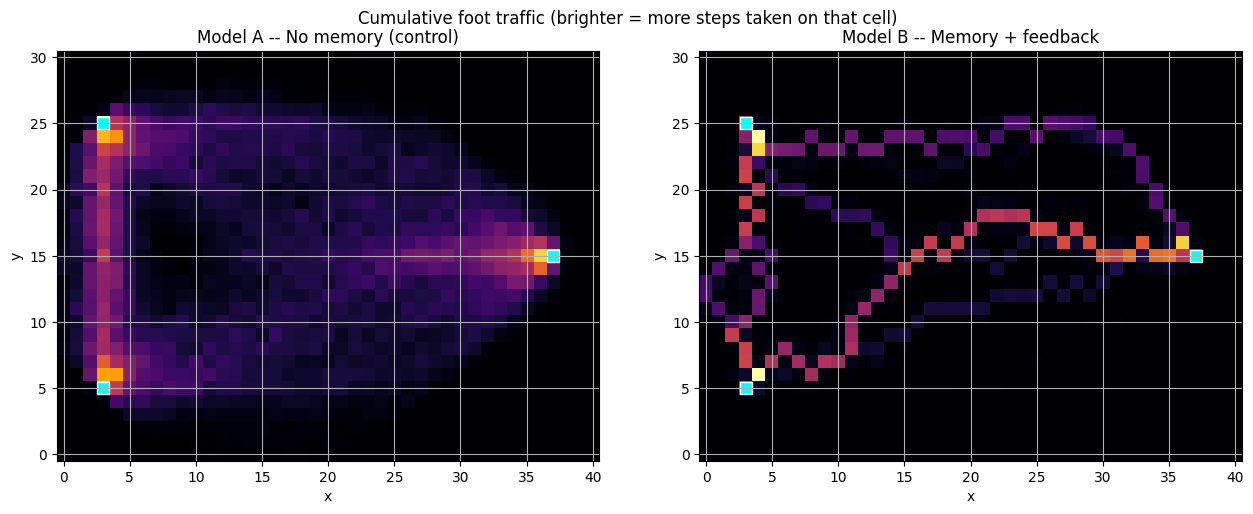

In [19]:
model_A = run_simulation(use_memory=False, seed=123)   # control: no memory
model_B = run_simulation(use_memory=True, seed=123)    # treatment: memory + feedback

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, popularity, title in [
    (axes[0], model_A, "Model A -- No memory (control)"),
    (axes[1], model_B, "Model B -- Memory + feedback"),
]:
    ax.imshow(popularity, origin="lower", cmap="inferno")
    bx, by = zip(*BUILDINGS)
    ax.scatter(bx, by, marker="s", s=80, c="cyan", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.suptitle("Cumulative foot traffic (brighter = more steps taken on that cell)")
plt.tight_layout()
plt.show()


### Step 5 — Summary statistics for the two models

A picture tells you *that* something is different. These numbers tell you **how**:

- **cells ever used** — how much of the map saw any traffic at all.
- **busiest cell's traffic** — the single most-walked-on cell's footstep count.
- **top-5% share** — of all footsteps taken, what fraction landed in the busiest 5% of used cells?
  Higher = more concentrated onto a few preferred routes.
- **traffic entropy** — a single number measuring how spread out the traffic is (higher = more
  spread out). Same idea as top-5% share, computed a different way, as a cross-check.


### Pseudocode — `summarize`

1. Keep only the cells that were used at least once
2. Sum up the total footsteps across all used cells
3. Sort the used cells by traffic, busiest first
4. Take the busiest 5% of used cells and add up their share of all footsteps
5. Compute the traffic entropy (a standard measure of how spread out a distribution is)
6. Return all of these numbers together, labeled with the model's name


In [20]:
def summarize(popularity, model_name):
    """Compute a few simple numbers describing how concentrated the foot traffic became."""
    used_cells = popularity[popularity > 0]                     # (1)
    total_footsteps = used_cells.sum()                          # (2)

    sorted_traffic = np.sort(used_cells)[::-1]                  # (3)
    n_top = max(1, int(len(sorted_traffic) * 0.05))             # (4)
    top5_share = sorted_traffic[:n_top].sum() / total_footsteps # (4)

    p = used_cells / total_footsteps                            # (5)
    traffic_entropy = -(p * np.log(p)).sum()                    # (5)

    return {                                                    # (6)
        "model": model_name,
        "total footsteps": int(total_footsteps),
        "cells ever used": int(len(used_cells)),
        "busiest cell's traffic": int(used_cells.max()),
        "top-5% share": round(top5_share, 3),
        "traffic entropy": round(traffic_entropy, 3),
    }

summary_table = pd.DataFrame([
    summarize(model_A, "A: No memory"),
    summarize(model_B, "B: Memory + feedback"),
]).set_index("model")

summary_table


,total footsteps,cells ever used,busiest cell's traffic,top-5% share,traffic entropy
model,,,,,
A: No memory,20000,933,176,0.209,6.451
B: Memory + feedback,20000,566,384,0.333,5.286


**What to read off this table:** Model B concentrates a noticeably larger share of all footsteps
onto a small set of cells, and has lower traffic entropy — both numbers agree that reflexive
feedback makes movement more organized around a few preferred routes, even though it doesn't use
noticeably more or fewer cells overall.


### Step 6 — The real test: does this repeat?

One run each isn't enough to know *what kind* of difference this is. Let's run both models 5
times, changing only the random seed, and see how much the results actually move around.


In [21]:
seeds = [1, 2, 3, 4, 5]

records = []
for model_name, use_memory in [("A: No memory", False), ("B: Memory + feedback", True)]:
    for seed in seeds:
        popularity = run_simulation(use_memory=use_memory, seed=seed)
        stats = summarize(popularity, model_name)
        stats["seed"] = seed
        records.append(stats)

repeated_runs = pd.DataFrame(records)
repeated_runs[["model", "seed", "top-5% share", "traffic entropy"]]


,model,seed,top-5% share,traffic entropy
0,A: No memory,1,0.203,6.454
1,A: No memory,2,0.206,6.456
2,A: No memory,3,0.197,6.472
3,A: No memory,4,0.200,6.459
4,A: No memory,5,0.198,6.463
5,B: Memory + feedback,1,0.349,5.251
6,B: Memory + feedback,2,0.362,5.113
7,B: Memory + feedback,3,0.323,5.123
8,B: Memory + feedback,4,0.330,5.286
9,B: Memory + feedback,5,0.395,5.138


In [22]:
reproducibility_summary = repeated_runs.groupby("model")[["top-5% share", "traffic entropy"]].agg(
    ["mean", "std", "min", "max"]
)
reproducibility_summary


top-5% share                         traffic entropy  \
                             mean       std    min    max            mean   
model                                                                       
A: No memory               0.2008  0.003701  0.197  0.206          6.4608   
B: Memory + feedback       0.3518  0.028648  0.323  0.395          5.1822   

                                              
                           std    min    max  
model                                         
A: No memory          0.007120  6.454  6.472  
B: Memory + feedback  0.080242  5.113  5.286

**What to read off this table:** compare the `std` (standard deviation) columns between the two
models. Model A's numbers barely move between runs — a small, tight `std`. Model B's numbers move
noticeably more, run to run, even though nothing about the rules or the setup changed — only which
random walker happened to be where, early on.

That's the signature of organized complexity in this notebook's operational sense: **organic
interrelation + reflexivity** together produce a group-level outcome that isn't reliably
predictable from the parameters alone. No amount of knowing `n_walkers`, `follow_probability`, or
the building layout in advance tells you exactly how concentrated Model B's traffic will end up
being — you have to run it and see.

Worth being precise about scope: this demonstrates *a* mechanism for organized complexity — the
one complexity science later supplied — not Weaver's own argument, and the "memory" doing the work
here is a simple popularity tally, not Simon's organizational memory (distributed expertise across
role-holders), which is a separate concept covered in Q2 of the course's mind map.


---
## Recap: all three of Weaver's cases, side by side

| | Case 1: Simplicity | Case 2: Disorganized | Case 3: Organized (Model A vs. B) |
|---|---|---|---|
| how many things involved | 2–3 | hundreds, independent | dozens, interdependent (Model B only) |
| organic interrelation? | n/a (too few variables) | no | Model A: no. Model B: yes |
| reflexivity? | n/a | no | Model A: no. Model B: yes |
| individually predictable? | yes, exactly | no | yes -- each walker follows its own rule |
| what varies between repeated runs | nothing (0% by construction) | individual paths, not the group average | Model B's *group-level* outcome itself |
| reproducible across seeds? | trivially, yes | yes, tightly, at the group level | Model A: yes. Model B: noticeably not |

**The key move in Case 3:** Model A already shows you what "goal-directed but uncoordinated"
looks like — no interrelation, no reflexivity, just like Case 2 in that narrow sense. The
organized-complexity signature only shows up once interrelation and reflexivity are added
together in Model B, and even then, it's borrowed machinery Weaver's own 1948 paper never
supplied.

**Next up:** an agent-based model that builds on this Case 3 mechanism directly — this is where
the course's core modeling toolkit begins.
